In [1]:
import pickle
import time
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari
print(nth_prime(100))

541


In [8]:
import pickle
import time
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari


pari.allocatemem(6*10**9) 
print(f"PARI stack size set to: {pari.stacksize() / 1e9:.2f} GB")


D = delta_qexp(545) 
print(nth_prime(100))
print(D[nth_prime(100)])

PARI stack size set to 6000000000 bytes, maximum size set to 6000001024
PARI stack size set to: 6.00 GB
541
-1695266465052058


In [12]:
add([1,2])

3

In [27]:
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari
print(nth_prime(500))

3571


In [6]:
from sage.all import sigma, nth_prime
from sage.arith.all import moebius
import pickle
import ast

def elliptic_fourier_expansions(level, num_terms):
    db = CremonaDatabase()
    expansions = []

    for curve_label in db.curves(level):
        if curve_label.endswith('1'):
            full_label = str(level) + curve_label
            E = EllipticCurve(full_label)
            coeffs = [(n, E.an(n)) for n in range(1, num_terms + 1)]
            expansions.append((full_label, coeffs))

    return expansions


def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("Must have h_0 = 1")
    h_lenth= len(h_list) - 1
    j = []
    for n in range(1, h_lenth + 1):
        s = sum(j[r-1] * h_list[n-r]
                for r in range(1, n))
        j_n = n*h_list[n] - s
        j.append(j_n)
    return j
    
level = 11
bound =3600
output = elliptic_fourier_expansions(level, bound)
data=output[0]
label = data[0]
expansion=data[1]
print("label:", label)
print("expansion[:5]:",expansion[:5])
prime_list_no_offset=[pair for pair in expansion if is_prime(pair[0])]
coeffs_list=[pair[1] for pair in prime_list_no_offset]
h_list=[1]+coeffs_list
j_list=j_sequence_from_h(h_list)
c=1 # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
deformed_j_list=[c]+j_list
print("new deformed j_list:")
print(deformed_j_list[:5])
print("old deformed j_list:")
old_deformed_j_list_pairs=[(0,1)] # first entry is just an offset. 
for n in range(1,501):# so j(1) = 1 = h(0) as required.
    sm=0
    for r in [1..n-1]: 
        sm=sm+old_deformed_j_list_pairs[r][1]*h_list[n-r] 
    j_n=n*h_list[n]-sm
    old_deformed_j_list_pairs.append((n,j_n))
old_j_list=[pair[1] for pair in old_deformed_j_list_pairs]
print(deformed_j_list[:5])

label: 11a1
expansion[:5]: [(1, 1), (2, -2), (3, -1), (4, 2), (5, 1)]
new deformed j_list:
[1, -2, -6, -11, -34]
old deformed j_list:
[1, -2, -6, -11, -34]


label: 11a1
deformed_h_list[0]: 1
n: 1 elapsed: 0.035867702960968015
n: 2 elapsed: 0.03629748423894246
n: 3 elapsed: 0.03630404869715373
n: 4 elapsed: 0.03659228483835856
n: 5 elapsed: 0.03660863240559896
n: 6 elapsed: 0.03663503726323446
n: 7 elapsed: 0.03666403690973918
n: 8 elapsed: 0.036700232823689775
n: 9 elapsed: 0.03674773375193278
n: 10 elapsed: 0.03680616617202759
n: 11 elapsed: 0.03687008619308472
n: 12 elapsed: 0.03695608377456665
n: 13 elapsed: 0.03703808784484863
n: 14 elapsed: 0.03713528315226237
n: 15 elapsed: 0.037245782216389973
n: 16 elapsed: 0.03738102118174235
n: 17 elapsed: 0.037518699963887535
n: 18 elapsed: 0.03767661650975545
n: 19 elapsed: 0.037851937611897785
n: 20 elapsed: 0.038045581181844076
n: 21 elapsed: 0.03825200001398722
n: 22 elapsed: 0.03847932020823161
n: 23 elapsed: 0.038712135950724286
n: 24 elapsed: 0.03894201914469401
n: 25 elapsed: 0.03921423355738322
n: 26 elapsed: 0.03950270016988119
n: 27 elapsed: 0.039799853165944414
n: 28 elapsed: 0.04013

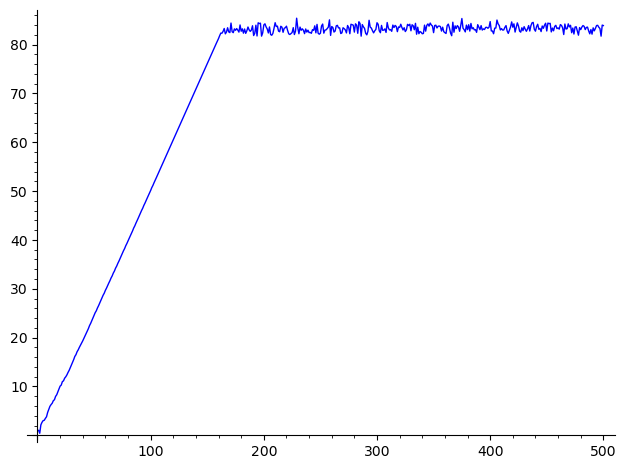

anomalies: 0 503
LOGPLOT


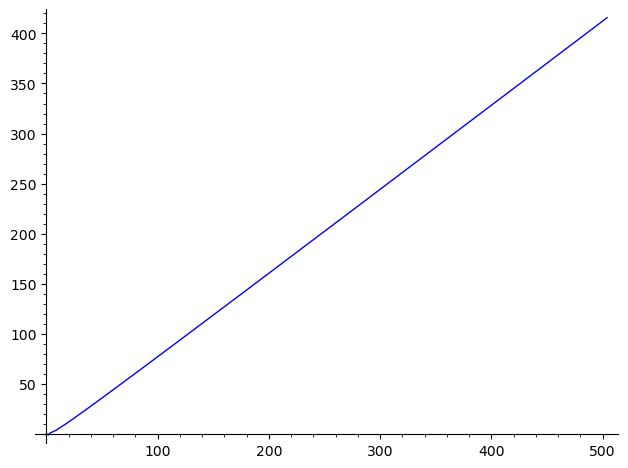

In [3]:
from sage.all import *
import pickle
import time
from sage.all import sigma, nth_prime, matrix, QQ, polygen, log, list_plot, flatten, pari
start=time.time()
precision_bits = 100
CC = ComplexField(precision_bits)
x = polygen(QQ)

def h_sequence_from_j(j_list):
    j_lenth = len(j_list)
    h = [QQ(1)]   # h_0 = 1
    for n in range(1, j_lenth + 1):
        s = sum(j_list[r-1] * h[n-r] for r in range(1, n))
        h_n = (j_list[n-1] + s) / n
        h.append(h_n)
    return h

def j_sequence_from_h(h_list):
    if h_list[0] != 1:
        raise ValueError("Must have h_0 = 1")
    h_lenth= len(h_list) - 1
    j = []
    for n in range(1, h_lenth + 1):
        s = sum(j[r-1] * h_list[n-r]
                for r in range(1, n))
        j_n = n*h_list[n] - s
        j.append(j_n)
    return j

level = 11
bound =3600
output = elliptic_fourier_expansions(level, bound)
data=output[0]
label = data[0]
expansion=data[1]
print("label:", label)
prime_list_no_offset=[pair for pair in expansion if is_prime(pair[0])]
coeffs_list=[pair[1] for pair in prime_list_no_offset]
h_list=[1]+coeffs_list
j_list=j_sequence_from_h(h_list)
c=1 # <<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<<
deformed_j_list=[c]+j_list
deformed_h_list=h_sequence_from_j(deformed_j_list)
print("deformed_h_list[0]:",deformed_h_list[0])

def deformed_h(n):
    return deformed_h_list[n]
    
roots_list=[]    
chi_list=[]
mins_list=[]
for n in range(1,501):
    print("n:",n,"elapsed:",(time.time()-start)/60)
    chi=0
    for r in range(0,n+1):
        chi+=binomial(n,r)*factorial(r)*deformed_h(r)*(-1)**r*x**(n-r)
    chi_list.append((n,chi))
    roots = chi.roots(ring=CC, multiplicities=False)
    roots_list.append((n, roots))
    aar = [r.abs() for r in roots]
    if aar:
        minn = min(aar)
        mins_list.append((n, minn))

p = list_plot(mins_list, plotjoined=True, axes_labels=['', ''])
print("MINIMUM MODULI")
p.show()

countzeros=0
countnegatives=0
for x in deformed_h_list:
    if x==0:
        countzeros+=1
    if x<0:countnegatives+=1
print("anomalies:",countzeros,countnegatives)   


logplot=[]
for x in deformed_h_list:
    if x==0:
        logplot.append(x)
    if x>0:
        logplot.append(RR(log(x)))
    if x<0:
        logplot.append(RR(log(-x)))

        
p = list_plot(logplot, plotjoined=True, axes_labels=['', ''])
print("LOGPLOT")
p.show()

chi_list_a=chi_list[:300]
chi_list_b=chi_list[301:400]
chi_list_c=chi_list[401:450]
chi_list_d=chi_list[450:480]
chi_list_e=chi_list[481:500]

with open('/Users/barrybrent/data2/run17may26no9.txt', 'wb') as wfile:
    pickle.dump(deformed_j_list, wfile) 
with open('/Users/barrybrent/data2/run17may26no10.txt', 'wb') as wfile:
    pickle.dump(deformed_h_list, wfile)
with open('/Users/barrybrent/data2/run17may26no11.txt', 'wb') as wfile:
    pickle.dump(mins_list, wfile)
with open('/Users/barrybrent/data2/run17may26no12.txt', 'wb') as wfile:
    pickle.dump(chi_list, wfile)
with open('/Users/barrybrent/data2/run17may26no12a.txt', 'wb') as wfile:
    pickle.dump(chi_list_a, wfile)
with open('/Users/barrybrent/data2/run17may26no12b.txt', 'wb') as wfile:
    pickle.dump(chi_list_b, wfile)
with open('/Users/barrybrent/data2/run17may26no12c.txt', 'wb') as wfile:
    pickle.dump(chi_list_c, wfile)
with open('/Users/barrybrent/data2/run17may26no12d.txt', 'wb') as wfile:
    pickle.dump(chi_list_d, wfile)
with open('/Users/barrybrent/data2/run17may26no12e.txt', 'wb') as wfile:
    pickle.dump(chi_list_e, wfile)